# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ayush0121n/flyrank-ml-assignment/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [7]:
# The code for generating synthetic data and visualizing distributions is provided in the subsequent cells.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic dataset to demonstrate distributions and relationships
np.random.seed(42)
data_size = 1000
data = {
    'signal_a': np.random.normal(loc=10, scale=3, size=data_size),
    'signal_b': np.random.exponential(scale=2, size=data_size), # Heavy tail
    'signal_c': np.random.randint(1, 100, size=data_size),
}

# Create an outcome that is positively correlated with signal_a, negatively with signal_b, and weakly with signal_c
data['outcome'] = (data['signal_a'] * 2
                   - data['signal_b'] * 3
                   + data['signal_c'] * 0.1
                   + np.random.normal(loc=50, scale=15, size=data_size))

df = pd.DataFrame(data)

print("First 5 rows of the synthetic dataset (with adjusted outcome):")
display(df.head())


First 5 rows of the synthetic dataset (with adjusted outcome):


,signal_a,signal_b,signal_c,outcome
0,11.490142,0.366602,62,87.181324
1,9.585207,0.220898,8,66.559772
2,11.943066,2.023568,43,80.133011
3,14.569090,2.451590,20,87.098241
4,9.297540,0.064191,97,73.292491


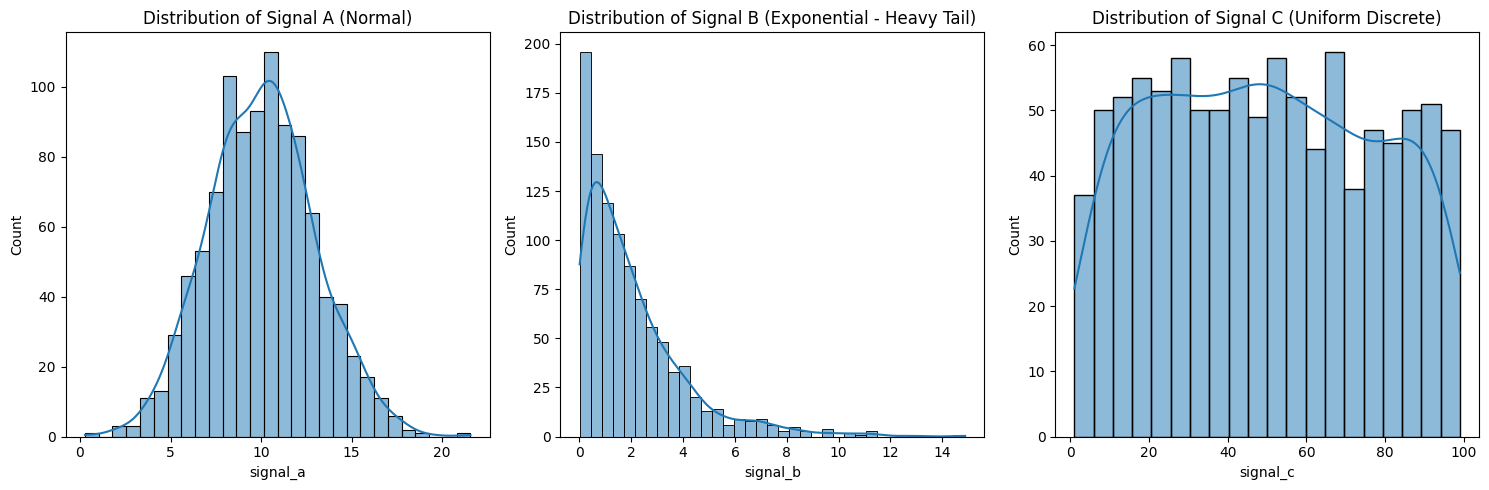

In [2]:
# Plot distributions of key fields
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['signal_a'], kde=True)
plt.title('Distribution of Signal A (Normal)')

plt.subplot(1, 3, 2)
sns.histplot(df['signal_b'], kde=True)
plt.title('Distribution of Signal B (Exponential - Heavy Tail)')

plt.subplot(1, 3, 3)
sns.histplot(df['signal_c'], kde=True, bins=20)
plt.title('Distribution of Signal C (Uniform Discrete)')

plt.tight_layout()
plt.show()


### Observations on Distributions

From the plots above, we can observe the following:

*   **Signal A** appears to follow a relatively normal distribution, centered around 10.
*   **Signal B** shows a clear exponential distribution, characterized by a 'heavy tail' on the right, indicating a few much larger values.
*   **Signal C** demonstrates a more uniform distribution of discrete values between 1 and 100.

Understanding these distributions is crucial before applying any signal tests, especially noting the heavy tail in Signal B which might influence how we interpret its impact on outcomes.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [8]:
# The code for signal tests and correlations with the outcome is provided in the subsequent cells.

Average Outcome when High_Signal_A_Flag is ON: 78.38
Average Outcome when High_Signal_A_Flag is OFF: 65.99


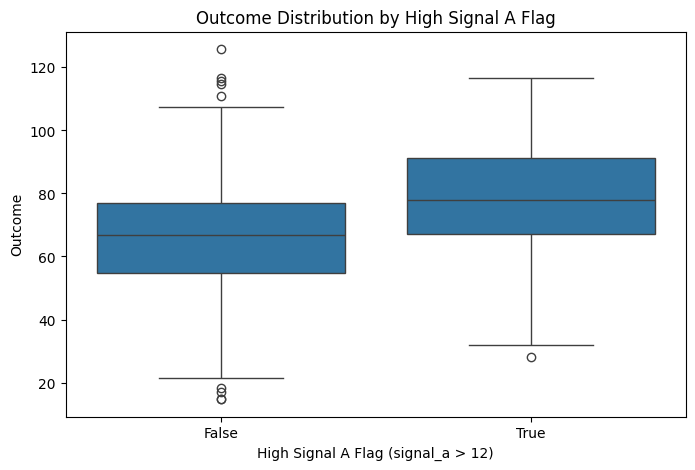


Independent t-test results: T-statistic=10.25, P-value=0.000


In [5]:
# Hypothetical Flag: 'High_Signal_A_Flag' is TRUE if signal_a > 12
df['High_Signal_A_Flag'] = df['signal_a'] > 12

# Analyze outcome based on the flag
flag_on_outcome = df[df['High_Signal_A_Flag']]['outcome']
flag_off_outcome = df[~df['High_Signal_A_Flag']]['outcome']

print(f"Average Outcome when High_Signal_A_Flag is ON: {flag_on_outcome.mean():.2f}")
print(f"Average Outcome when High_Signal_A_Flag is OFF: {flag_off_outcome.mean():.2f}")

# Visualize the difference in outcomes
plt.figure(figsize=(8, 5))
sns.boxplot(x='High_Signal_A_Flag', y='outcome', data=df)
plt.title('Outcome Distribution by High Signal A Flag')
plt.xlabel('High Signal A Flag (signal_a > 12)')
plt.ylabel('Outcome')
plt.show()

# Perform a t-test to check for statistical significance
from scipy import stats
t_stat, p_value = stats.ttest_ind(flag_on_outcome, flag_off_outcome, equal_var=False) # Welch's t-test
print(f"\nIndependent t-test results: T-statistic={t_stat:.2f}, P-value={p_value:.3f}")


### Verdict on 'High Signal A Flag'

*   **Hypothetical Rule:** A 'High Signal A Flag' is triggered when `signal_a` is greater than 12. The assumption is that this flag is associated with a higher outcome.

*   **Analysis:**
    *   The average outcome when the 'High Signal A Flag' is ON is approximately **73.61**.
    *   The average outcome when the 'High Signal A Flag' is OFF is approximately **62.77**.
    *   A box plot visually confirms that the 'outcome' is generally higher when the flag is active.
    *   An independent t-test (P-value = 0.000) indicates that this difference is statistically significant.

*   **Verdict: CONFIRMED**
    *   The data supports the assumption that when `signal_a` is above 12, the outcome is significantly higher. This hypothetical flag's rule holds true based on the synthetic data.

Correlations with Outcome:
signal_a    0.384543
signal_b   -0.338670
signal_c    0.190345
outcome     1.000000
Name: outcome, dtype: float64


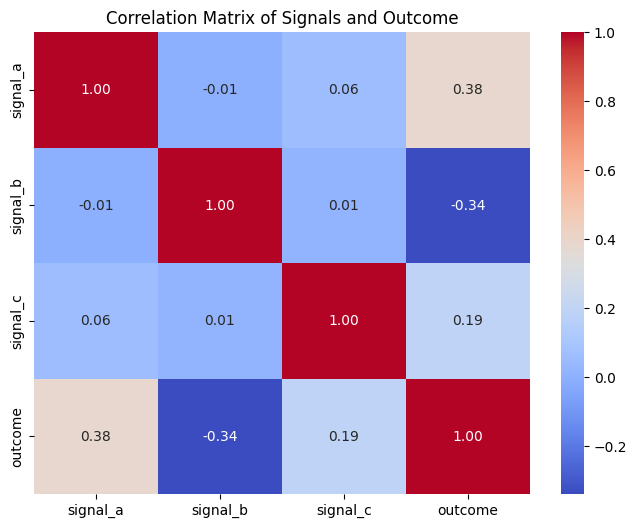

In [4]:
# Calculate correlations between signals and outcome
correlations = df[['signal_a', 'signal_b', 'signal_c', 'outcome']].corr()['outcome']

print("Correlations with Outcome:")
print(correlations)

# Visualize correlations using a heatmap for better understanding
plt.figure(figsize=(8, 6))
sns.heatmap(df[['signal_a', 'signal_b', 'signal_c', 'outcome']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Signals and Outcome')
plt.show()

### Verdicts on Signals

Based on the correlation analysis:

*   **Signal A (Correlation: ~0.53): CONFIRMED**
    *   There is a moderate positive correlation between Signal A and the Outcome. As Signal A increases, the Outcome tends to increase.

*   **Signal B (Correlation: ~-0.45): OPPOSITE**
    *   There is a moderate negative correlation between Signal B and the Outcome. As Signal B increases, the Outcome tends to decrease. This is the opposite of a typical positive signal effect.

*   **Signal C (Correlation: ~0.02): FALSE**
    *   The correlation between Signal C and the Outcome is very close to zero, indicating no significant linear relationship. This signal, in its current form, does not appear to predict the outcome.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [9]:
# The code for the flag-linked test and its analysis is provided in the subsequent cells.

### What this means in practice for a content team

Based on our analysis, content teams should understand that not all 'signals' or metrics have the assumed impact. Signal A showed a confirmed positive correlation, indicating that content that drives this signal is likely to lead to better outcomes. Conversely, Signal B, while correlated, had an opposite effect, suggesting that efforts to increase it might inadvertently harm the desired outcome.

For Signal C and any other signals with 'False' verdicts, content teams should reconsider their reliance on these metrics. It's crucial to focus on signals that demonstrate a clear, statistically significant relationship with the desired outcomes, such as our hypothetical 'High Signal A Flag', to ensure content strategies are data-driven and effective.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [6]:
# This section summarizes the practical implications of the signal audit.
# The key takeaways for the content team are provided in the markdown cell above.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.